In [29]:
import os
from pathlib import Path

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
import numpy as np

import torch
import torch.nn.functional as F
import torchvision.transforms as T

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [10]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Подготовка данных

In [2]:
BASE_DIR = Path.cwd()
print(BASE_DIR)

/home/evgeniy/Документы/GitHub/YandexNN/sprint_4


In [3]:
dataset_path = BASE_DIR / "data" / "faces"
train_dataset_path = dataset_path / "db"
test_dataset_path = dataset_path / "new"

In [20]:
class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images_path = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith(('.jpg', '.PNG'))]
        self.transform = transform
        
    def __len__(self):
        return len(self.images_path)

    def __getitem__(self, idx):
        img_path = self.images_path[idx]
        image = Image.open(img_path).convert('RGB')

        # применяем трансформацию
        if self.transform:
            image = self.transform(image)

        return image, img_path

In [21]:
model_name = 'tf_efficientnet_b0'
cfg = timm.get_pretrained_cfg(model_name)

transform = T.Compose([
    T.Resize(cfg.input_size[1:]),
    T.ToTensor(),
    T.Normalize(mean=cfg.mean, std=cfg.std),
])

In [22]:
# Создаём DataLoader для проверенных и новых изображений
db_dataset = FaceDataset(train_dataset_path.resolve(), transform)
new_dataset = FaceDataset(test_dataset_path.resolve(), transform)

db_loader = DataLoader(db_dataset, batch_size=2, num_workers=2)
new_loader = DataLoader(new_dataset, batch_size=2, num_workers=2)

# Использование модели

In [44]:
def get_embeddings(loader, model):
    model = model.to(device)
    
    embeddings = []
    paths = []
    with torch.no_grad():
        for images, batch_paths in loader:
            images = images.to(device)
            features = model(images)

            # используем пуллинг для агрегации и конкатенируем
            features = torch.cat([F.avg_pool2d(x, (x.size(-2), x.size(-1))) for x in features], dim=1).squeeze((-1, -2))

            embeddings.append(features.cpu())
            paths.extend(batch_paths)
            images = images.to("cpu")

    model.to("cpu")
    return torch.cat(embeddings, dim=0), np.array(paths)

In [45]:
model = timm.create_model(model_name, 
                          pretrained=True, 
                          features_only=True, 
                          out_indices=[3,4])
model.eval()

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


EfficientNetFeatures(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): B

In [46]:
# Получаем эмбеддинги для проверенных и новых изображений
db_embeddings, db_paths = get_embeddings(db_loader, model)
new_embeddings, new_paths = get_embeddings(new_loader, model)

# Опционально сохраним для переиспользования
torch.save(db_embeddings, f="data/faces/db_embeddings.pt")
torch.save(new_embeddings, f="data/faces/new_embeddings.pt")

file_path = 'data/faces/new_paths'
np.save(file_path, np.array(new_paths))

print(new_embeddings.shape)

torch.Size([9, 432])


In [47]:
def display_images(image_paths, figsize=(12, 3)):
    """
    Отображает изображения из списка путей в одну строку (горизонтально)
    """
    num_images = len(image_paths)

    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    fig.subplots_adjust(wspace=0.2)

    # Отображаем изображения
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = Image.open(image_paths[i])
            ax.imshow(img)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [48]:
def find_invalid_images(new_embeddings, db_embeddings, new_paths, threshold=0.68):
    # Нормализуем эмбеддинги
    db_embeddings = F.normalize(db_embeddings, p=2, dim=1)
    new_embeddings = F.normalize(new_embeddings, p=2, dim=1)

    # Вычисляем косинусное сходство между новыми изображениями и архивными
    similarities = cosine_similarity(new_embeddings.numpy(), db_embeddings.numpy())
    max_similarities = similarities.max(axis=1)

    # Определяем, какие изображения не соответствуют формату
    invalid_mask = max_similarities < threshold
    invalid_paths = new_paths[invalid_mask]

    return invalid_paths, max_similarities

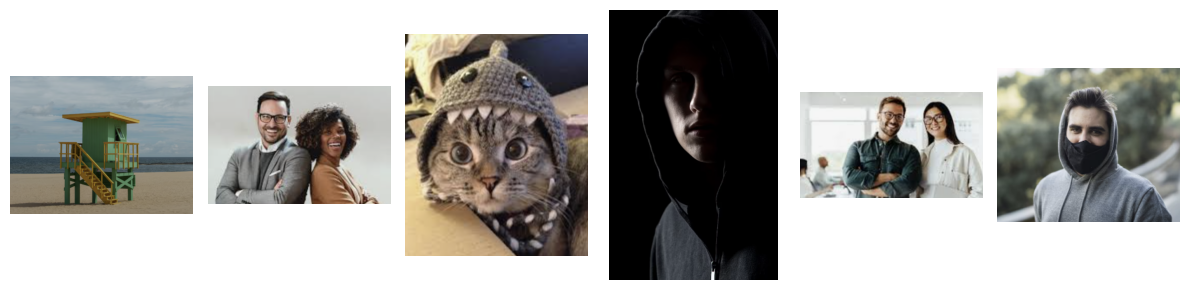

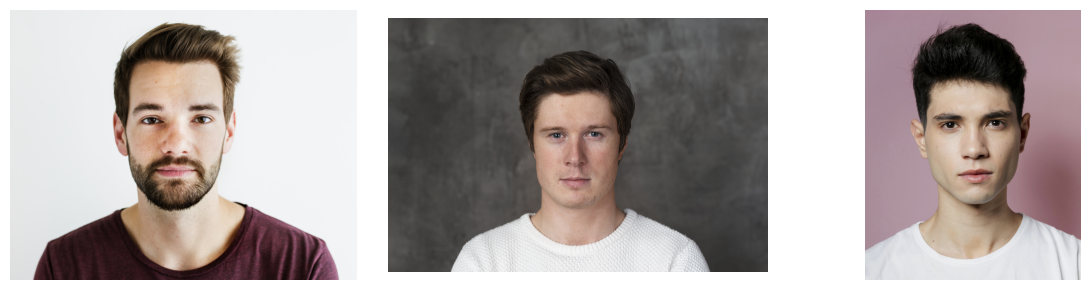

In [49]:
invalid_images, similarities = find_invalid_images(new_embeddings, db_embeddings, new_paths)

# Визуализируем фото, не прошедшие проверку
display_images(invalid_images)
# Визуализируем фото, прошедшие проверку
display_images(list(set(new_paths).difference(invalid_images))) 